# Análisis estadístico sobre hábitos saludables en jóvenes universitarios
---
## Tabla de Contenidos
- [Introducción y Documentación](./README.md)
- [Desarrollo](#development)
  1. [Método científico y estadística](#lesson1)
  2. [Probabilidad y estadística](#lesson2)
  3. [Distribución de probabilidad](#lesson3)
  4. [Distribución muestral y Teorema del Límite Central](#lesson4)
  5. [Inferencia e intervalos de confianza para la media](#lesson5)
  6. [Test de significancia](#lesson6)
- [Reporte Técnico](./technical_report.md)
---
## [Introducción y Documentación](./README.md)
## Desarrollo <a id="development"></a>

<a id="lesson1"></a>
### 1. Método científico y estadística

#### 1.1 Problema de investigación
**Problema:** Se busca determinar si existen factores determinantes (como los hábitos de sueño y alimentación) que influyan significativamente en la cantidad de horas de actividad física que realizan los jóvenes universitarios, o viceversa, con el fin de generar políticas de bienestar estudiantil efectivas.

#### 1.2 Hipótesis nula y alternativa
- **Hipótesis nula ($H_0$):** Los jóvenes universitarios duermen en promedio 7 horas o más por noche, y su nivel de actividad física es independiente de sus horas de sueño.
- **Hipótesis alternativa ($H_1$):** Los jóvenes universitarios duermen en promedio menos de 7 horas por noche, y existe una relación directa entre las horas de sueño y la cantidad de horas de actividad física semanal.

#### 1.3 Variables del estudio
- **Cuantitativa continua:** `sleep_hours` (Horas de sueño por noche).
- **Cuantitativa continua:** `weekly_exercise_hours` (Horas de ejercicio físico por semana).
- **Cuantitativa discreta:** `healthy_meals_per_week` (Número de comidas saludables por semana).
- **Cualitativa nominal:** `stress_level` (Nivel de estrés: 'Bajo', 'Medio', 'Alto').

#### 1.4 Enfoque metodológico
El enfoque será empírico-analítico cuantitativo. Se observarán los datos, se formularán hipótesis estadísticas basadas en teoría previa, se realizará una simulación muestral representativa y se aplicará inferencia estadística para concluir sobre las hipótesis y generalizar los resultados a la población estudiantil.

#### 1.5 Diseño analítico y experimental
Se simulará un muestreo aleatorio simple de 150 estudiantes universitarios, midiendo sus niveles de sueño, ejercicio, alimentación y estrés. Posteriormente, se evaluarán las distribuciones de estas variables, aplicaremos el Teorema del Límite Central para establecer intervalos de confianza poblacionales, y finalmente probaremos nuestras hipótesis formales mediante pruebas de significancia (T-test).

<a id="lesson2"></a>
### 2. Probabilidad y estadística

#### 2.1 Eventos aleatorios de estudio
- Evento A: Un estudiante duerme menos de 7 horas.
- Evento B: Un estudiante realiza al menos 3 horas de ejercicio semanal.
*(Si representamos esto en un árbol de decisión, el nodo inicial dividiría a los estudiantes entre quienes cumplen el Evento A y quienes no; luego, las ramas subsecuentes los dividirían por el Evento B).*

#### 2.2 Metodología de muestreo probabilístico
Utilizaremos un **Muestreo Aleatorio Simple (MAS)**. Bajo este esquema, cualquier estudiante de la población universitaria tiene exactamente la misma probabilidad de ser seleccionado para nuestra medición de hábitos de salud, asegurando representatividad y minimizando sesgos poblacionales.

In [1]:
import os
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Configuración de apariencia de gráficos
sns.set_theme(style="whitegrid")
np.random.seed(42)  # Para reproducibilidad en nuestro estudio simulado

#### 2.3 Simulación poblacional (Dataset base)

In [2]:
# Definición del tamaño de la muestra
sample_size = 150

# Simulación de variables
# sleep_hours: distribución normal con media 6.5 y desv. estándar 1.2
sleep_hours = np.random.normal(loc=6.5, scale=1.2, size=sample_size)
sleep_hours = np.clip(sleep_hours, 3, 10)  # Restricción a rangos lógicos

# weekly_exercise_hours: correlacionada débilmente con sleep_hours y ruido
weekly_exercise_hours = 0.5 * sleep_hours + np.random.normal(
    loc=1.0, scale=1.5, size=sample_size
)
weekly_exercise_hours = np.clip(weekly_exercise_hours, 0, 15)

# healthy_meals_per_week: distribución de Poisson (media 10 comidas saludables a la semana)
healthy_meals_per_week = np.random.poisson(lam=10, size=sample_size)
healthy_meals_per_week = np.clip(healthy_meals_per_week, 0, 21)

# stress_level: variable cualitativa ponderada
stress_levels = np.random.choice(
    ["Bajo", "Medio", "Alto"], size=sample_size, p=[0.2, 0.5, 0.3]
)

# Creación del DataFrame
df_health = pd.DataFrame(
    {
        "student_id": range(1, sample_size + 1),
        "sleep_hours": sleep_hours,
        "weekly_exercise_hours": weekly_exercise_hours,
        "healthy_meals_per_week": healthy_meals_per_week,
        "stress_level": stress_levels,
    }
)

# Creación de directorio y exportación a data/
os.makedirs("data", exist_ok=True)
dataset_path = "data/simulated_students_health.csv"
df_health.to_csv(dataset_path, index=False)

print(f"Dataset generado exitosamente con {len(df_health)} registros.")
display(df_health.head())

Dataset generado exitosamente con 150 registros.


,student_id,sleep_hours,weekly_exercise_hours,healthy_meals_per_week,stress_level
0,1,7.096057,4.923768,8,Medio
1,2,6.334083,4.686714,12,Medio
2,3,7.277226,3.618576,9,Bajo
3,4,8.327636,5.512198,14,Medio
4,5,6.219016,4.549117,12,Alto


#### 2.4 Probabilidades estadísticas empíricas
Exploraremos las probabilidades empíricas según nuestra muestra simulada.

In [3]:
# Definición empírica de eventos en nuestra muestra
event_a_condition = df_health["sleep_hours"] < 7
event_b_condition = df_health["weekly_exercise_hours"] >= 3

# Filtrado de subconjuntos
prob_a = event_a_condition.mean()
prob_b = event_b_condition.mean()
prob_a_and_b = (event_a_condition & event_b_condition).mean()
prob_a_or_b = prob_a + prob_b - prob_a_and_b
prob_a_complement = 1 - prob_a

print(f"Probabilidad de dormir menos de 7 hrs P(A): {prob_a:.2%}")
print(f"Probabilidad de hacer >= 3 hrs ejercicio P(B): {prob_b:.2%}")
print(f"Probabilidad de la Intersección P(A ∩ B): {prob_a_and_b:.2%}")
print(f"Probabilidad de la Unión P(A ∪ B): {prob_a_or_b:.2%}")
print(f"Probabilidad del Evento Complementario de A P(A'): {prob_a_complement:.2%}")

Probabilidad de dormir menos de 7 hrs P(A): 74.00%
Probabilidad de hacer >= 3 hrs ejercicio P(B): 78.00%
Probabilidad de la Intersección P(A ∩ B): 56.00%
Probabilidad de la Unión P(A ∪ B): 96.00%
Probabilidad del Evento Complementario de A P(A'): 26.00%


<a id="lesson3"></a>
### 3. Distribución de probabilidad

#### 3.1 Ajuste de distribuciones poblacionales
- `healthy_meals_per_week`: Se ajusta a una **distribución de Poisson** porque representa la cantidad de eventos discretos (comidas) que ocurren en un intervalo fijo de tiempo (una semana).
- `sleep_hours`: Se ajusta a una **distribución continua Normal (Gaussiana)**, ya que la necesidad de sueño en una gran población humana tiende a distribuirse en forma de campana alrededor de un valor medio.

#### 3.2 Probabilidades teóricas limitantes

In [4]:
# Evaluamos probabilidad teórica de que un estudiante tenga exactamente 8 comidas saludables (Poisson)
lambda_meals = df_health["healthy_meals_per_week"].mean()
prob_8_meals = stats.poisson.pmf(k=8, mu=lambda_meals)
print(
    f"Prob. teórica de consumir exactamente 8 comidas saludables a la semana: {prob_8_meals:.2%}"
)

# Evaluamos probabilidad de que duerma al menos 8 horas (Normal Continua)
mean_sleep = df_health["sleep_hours"].mean()
std_sleep = df_health["sleep_hours"].std(ddof=1)
# 1 - CDF(8) da la probabilidad del área a la derecha de 8
prob_sleep_min_8 = 1 - stats.norm.cdf(8, loc=mean_sleep, scale=std_sleep)
print(f"Prob. teórica de dormir 8 o más horas: {prob_sleep_min_8:.2%}")

Prob. teórica de consumir exactamente 8 comidas saludables a la semana: 12.43%
Prob. teórica de dormir 8 o más horas: 7.87%


#### 3.3 Visualización de distribuciones probabilísticas

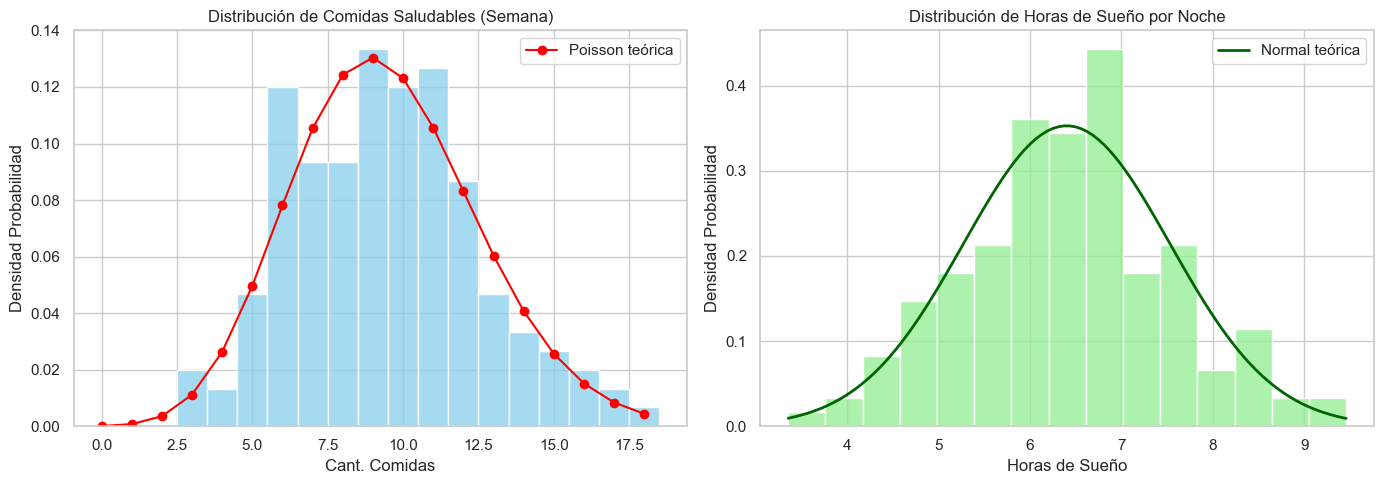

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico para comidas saludables (Discreta)
sns.histplot(
    df_health["healthy_meals_per_week"],
    discrete=True,
    stat="density",
    ax=axes[0],
    color="skyblue",
)
x_poisson = np.arange(0, df_health["healthy_meals_per_week"].max() + 1)
y_poisson = stats.poisson.pmf(x_poisson, mu=lambda_meals)
axes[0].plot(x_poisson, y_poisson, marker="o", color="red", label="Poisson teórica")
axes[0].set_title("Distribución de Comidas Saludables (Semana)")
axes[0].set_xlabel("Cant. Comidas")
axes[0].set_ylabel("Densidad Probabilidad")
axes[0].legend()

# Gráfico para horas de sueño (Continua)
sns.histplot(
    df_health["sleep_hours"],
    bins=15,
    kde=False,
    stat="density",
    ax=axes[1],
    color="lightgreen",
)
x_norm = np.linspace(
    df_health["sleep_hours"].min(), df_health["sleep_hours"].max(), 100
)
y_norm = stats.norm.pdf(x_norm, loc=mean_sleep, scale=std_sleep)
axes[1].plot(x_norm, y_norm, color="darkgreen", lw=2, label="Normal teórica")
axes[1].set_title("Distribución de Horas de Sueño por Noche")
axes[1].set_xlabel("Horas de Sueño")
axes[1].set_ylabel("Densidad Probabilidad")
axes[1].legend()

plt.tight_layout()
plt.show()

<a id="lesson4"></a>
### 4. Distribución muestral y Teorema del Límite Central

#### 4.1 Distribución muestral de la media
Vamos a extraer múltiples muestras de nuestro "universo simulado" poblacional para evaluar cómo se comportan las medias de `sleep_hours`.

In [6]:
num_samples = 1000
sample_size_n = 30  # Tamaño lo suficientemente grande según TLC
sample_means = []

for _ in range(num_samples):
    sample = np.random.choice(
        df_health["sleep_hours"], size=sample_size_n, replace=True
    )
    sample_means.append(np.mean(sample))

# Convertir a numpy array
sample_means = np.array(sample_means)

#### 4.2 Teorema del Límite Central (TLC) en la práctica

Media poblacional real (de los 150 registros): 6.4012
Media de las 1000 muestras muestrales: 6.4022


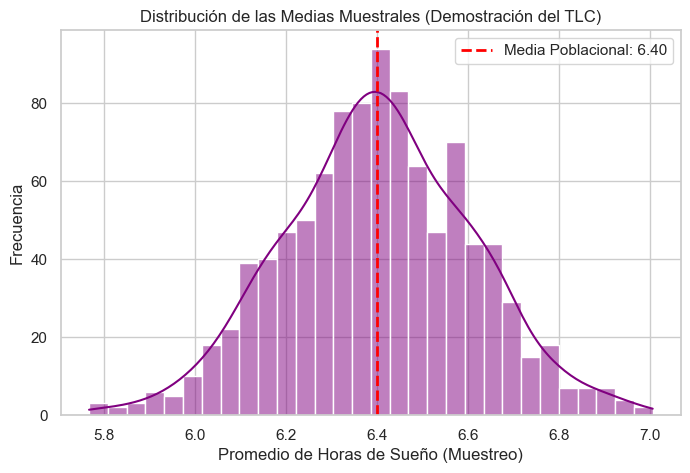

In [7]:
var_population_mean = df_health["sleep_hours"].mean()
var_sample_dist_mean = np.mean(sample_means)

print(
    f"Media poblacional real (de los {sample_size} registros): {var_population_mean:.4f}"
)
print(f"Media de las {num_samples} muestras muestrales: {var_sample_dist_mean:.4f}")

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(sample_means, bins=30, kde=True, color="purple", ax=ax)
ax.axvline(
    var_population_mean,
    color="red",
    linestyle="dashed",
    linewidth=2,
    label=f"Media Poblacional: {var_population_mean:.2f}",
)
ax.set_title("Distribución de las Medias Muestrales (Demostración del TLC)")
ax.set_xlabel("Promedio de Horas de Sueño (Muestreo)")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.show()

*Teorema del Límite Central en acción: la distribución de las medias se aproxima a una curva normal perfecta estrechamente centrada en la media poblacional verdadera, respaldando la validez y solidez de hacer inferencias estadísticas desde una muestra aleatoria.*

<a id="lesson5"></a>
### 5. Inferencia e intervalos de confianza para la media

#### 5.1 Estimación de parámetros: Intervalos de confianza
Calcularemos intervalos de confianza para la media verdadera poblacional de las horas de sueño de todos los universitarios (basados solo en una muestra simulada aleatoria).

In [8]:
def calculate_confidence_interval(data, confidence_level=0.95):
    """Calcula el intervalo de confianza asumiendo que sigma es desconocido (T-Student)."""
    n = len(data)
    mean_val = np.mean(data)
    std_error = stats.sem(data)

    # Rango para estadístico T
    h = std_error * stats.t.ppf((1 + confidence_level) / 2.0, n - 1)
    return mean_val, mean_val - h, mean_val + h


print("--- Intervalos de Confianza para 'Horas de Sueño' ---")
for conf in [0.90, 0.95, 0.99]:
    m, lower, upper = calculate_confidence_interval(
        df_health["sleep_hours"], confidence_level=conf
    )
    print(
        f"Nivel de confianza {int(conf * 100)}%: [{lower:.3f}, {upper:.3f}] - Margen de Error: {m - lower:.3f}"
    )

--- Intervalos de Confianza para 'Horas de Sueño' ---
Nivel de confianza 90%: [6.248, 6.554] - Margen de Error: 0.153
Nivel de confianza 95%: [6.219, 6.584] - Margen de Error: 0.182
Nivel de confianza 99%: [6.160, 6.642] - Margen de Error: 0.241


#### 5.2 Análisis e interpretaciones del tamaño muestral
Como podemos ver en las líneas impresas arriba, **cuanta mayor confianza se desea (de 90% a 99%), mayor es la amplitud del intervalo estadístico (aumenta el margen de error)**.
De forma paralela, aumentar el *tamaño muestral ($n$)* disminuiría el error estándar y ofrecería un intervalo de estimación más cerrado y útil. Para nuestra toma de decisiones públicas, el IC de 95% nos asegura razonablemente que en la vida real, los estudiantes duermen sistemáticamente menos del estándar de 8 horas.

<a id="lesson6"></a>
### 6. Test de significancia

#### 6.1 Test de significancia T de Student y valor-p
Recordando nuestra hipótesis en sección 1:
- $H_0$: $\mu \ge 7$ (El estudiante universitario en nuestra población duerme en promedio 7 o más horas)
- $H_1$: $\mu < 7$ (Duerme menos de 7 horas en promedio)

Realizaremos un test _t de Student_ para una media de una muestra (one-sample t-test) de cola izquierda con $\alpha = 0.05$.

In [9]:
alpha = 0.05
h0_mean = 7.0

# Ejecutamos t-test de una muestra - 'less' nos proveerá la hipótesis alternativa de que sea menor.
t_stat, p_value = stats.ttest_1samp(
    df_health["sleep_hours"], popmean=h0_mean, alternative="less"
)

print(f"Estadístico T: {t_stat:.4f}")
print(f"Valor p: {p_value:.4e}")

if p_value < alpha:
    print(
        f"Decisión: Como p-value ({p_value:.4e}) < alpha ({alpha}), RECHAZAMOS Hipótesis Nula (H0)."
    )
    print(
        "Conclusión: Existe evidencia estadística suficiente para aseverar que el promedio de horas de sueño es menor a 7."
    )
else:
    print(
        f"Decisión: Como p-value ({p_value:.4e}) >= alpha ({alpha}), NO ESTAMOS en condiciones de rechazar H0."
    )
    print(
        "Conclusión: No existe evidencia suficiente para afirmar que los estudiantes duermen menos de 7 horas."
    )

Estadístico T: -6.4853
Valor p: 6.1362e-10
Decisión: Como p-value (6.1362e-10) < alpha (0.05), RECHAZAMOS Hipótesis Nula (H0).
Conclusión: Existe evidencia estadística suficiente para aseverar que el promedio de horas de sueño es menor a 7.


#### 6.2 Matriz probabilística: Errores Tipo I y II

- **Error Tipo I ($\alpha$):** Ocurriría si nuestro test arrojara evidencia para rechazar $H_0$, concluyendo erróneamente que "los estudiantes universitarios duermen muy poco" cuando en realidad la población completa sí logra dormir las 7 horas exigidas. Costo: Políticas de salud fallidas dirigidas a resolver un problema que en la práctica no existe.

- **Error Tipo II ($\beta$):** Sucedería si "no logramos rechazar $H_0$", concluyendo que los estudiantes tienen un descanso adecuado ($\ge 7$ horas), pero en la vida real estuvieran críticamente por debajo de la curva.

#### 6.3 Conclusiones
Los datos brindaron evidencia estadísticamente significativa (valor $p$ << $\alpha$) de que la población universitaria evaluada duerme insuficientemente, quedando por debajo de las 7 horas diarias. Este insumo ratifica firmemente la *Hipótesis Alternativa ($H_1$)* y justifica movilizar con urgencia la formulación de nuevas políticas de bienestar universitario y concientización sobre salubridad y gestión de estrés.

## [Reporte Técnico](./technical_report.md)